In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Forma reconstruida: (494, 370, 3)


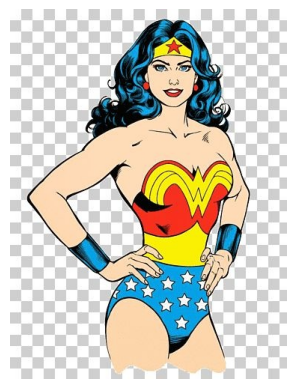

In [7]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Leer el Excel
df = pd.read_excel("/content/drive/MyDrive/mujer_maravilla_matriz.xlsx")

# 2Convertir a matriz numpy
pixeles = df.values

# 3️ Reconstruir matriz 3D
alto = 494
ancho = 370

matriz_rgb = pixeles.reshape(alto, ancho, 3)

print("Forma reconstruida:", matriz_rgb.shape)

# Convertir a imagen
imagen_reconstruida = Image.fromarray(matriz_rgb.astype('uint8'))

# Mostrar imagen
plt.imshow(imagen_reconstruida)
plt.axis("off")
plt.show()

In [20]:
from google.colab import drive
drive.mount('/content/drive')

from openpyxl import load_workbook
import pandas as pd

ruta_excel = "/content/drive/MyDrive/sistema_de_informacion_gerencial/mujer maravill_v1.xlsx"


wb = load_workbook(ruta_excel)
ws = wb.active

matriz = []

for row in ws.iter_rows():
    fila_rgb = []
    for cell in row:
        fill = cell.fill.start_color.rgb

        if fill is not None and len(fill) == 8:
            hex_color = fill[2:]
            r = int(hex_color[0:2], 16)
            g = int(hex_color[2:4], 16)
            b = int(hex_color[4:6], 16)

            fila_rgb.append(f"{r},{g},{b}")
        else:
            fila_rgb.append("0,0,0")

    matriz.append(fila_rgb)

df = pd.DataFrame(matriz)

ruta_salida = "/content/drive/MyDrive/mujer_maravilla_rgb_formato_imagen.xlsx"
df.to_excel(ruta_salida, index=False, header=False)

print("Excel con estructura de imagen guardado ✔")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Excel con estructura de imagen guardado ✔


In [21]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import PatternFill

#  Ruta del Excel con texto RGB
ruta_excel = "/content/drive/MyDrive/mujer_maravilla_rgb_formato_imagen.xlsx"

# Leer Excel
df = pd.read_excel(ruta_excel, header=None)

alto, ancho = df.shape

# Crear nuevo Excel
wb = Workbook()
ws = wb.active

# Pintar cada celda según su RGB
for i in range(alto):
    for j in range(ancho):
        valor = df.iloc[i, j]

        if isinstance(valor, str) and "," in valor:
            r, g, b = map(int, valor.split(","))
            color_hex = f"{r:02X}{g:02X}{b:02X}"

            ws.cell(row=i+1, column=j+1).fill = PatternFill(
                start_color=color_hex,
                end_color=color_hex,
                fill_type="solid"
            )

#  Ajustar tamaño
for col in range(1, ancho + 1):
    ws.column_dimensions[ws.cell(row=1, column=col).column_letter].width = 2

for row in range(1, alto + 1):
    ws.row_dimensions[row].height = 12

# Guardar archivo final
ruta_salida = "/content/drive/MyDrive/mujer_maravilla_imagen_en_excel.xlsx"
wb.save(ruta_salida)

print("Excel con imagen reconstruida guardado ✔")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Excel con imagen reconstruida guardado ✔
